In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics
!pip install -q opencv-python
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.8 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torchvision

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

In [4]:
!git clone https://github.com/alexgkendall/SegNet-Tutorial.git

Cloning into 'SegNet-Tutorial'...
remote: Enumerating objects: 2785, done.
remote: Total 2785 (delta 0), reused 0 (delta 0), pack-reused 2785 (from 1)
Receiving objects: 100% (2785/2785), 340.84 MiB | 20.59 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [5]:
import os

base = "SegNet-Tutorial/CamVid"

print("Train Images :", len(os.listdir(base + "/train")))
print("Train Masks  :", len(os.listdir(base + "/trainannot")))

print("Validation Images :", len(os.listdir(base + "/val")))
print("Validation Masks  :", len(os.listdir(base + "/valannot")))

print("Test Images :", len(os.listdir(base + "/test")))
print("Test Masks  :", len(os.listdir(base + "/testannot")))

Train Images : 367
Train Masks  : 367
Validation Images : 101
Validation Masks  : 101
Test Images : 233
Test Masks  : 233


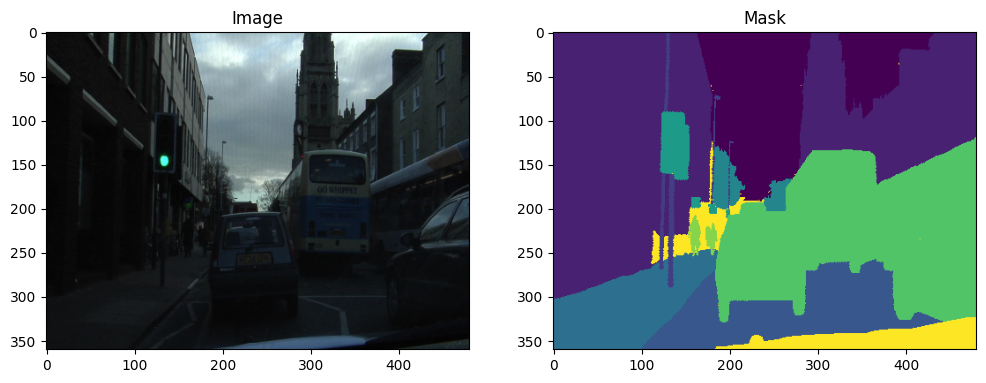

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "SegNet-Tutorial/CamVid"

img_name = sorted(os.listdir(base + "/train"))[0]

image = Image.open(os.path.join(base, "train", img_name))
mask = Image.open(os.path.join(base, "trainannot", img_name))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

In [7]:
print(image.size)
print(mask.size)

(480, 360)
(480, 360)


In [8]:
import numpy as np

mask_np = np.array(mask)

print(mask_np.shape)
print(np.unique(mask_np)[:20])

(360, 480)
[ 0  1  2  3  4  5  6  8  9 11]


In [9]:
class CamVidDataset(Dataset):
    def __init__(self, root, split="train", transforms=None):
        self.root = root
        self.split = split
        self.transforms = transforms

        self.images_dir = os.path.join(root, split)
        self.masks_dir = os.path.join(root, split + "annot")

        self.images = sorted(os.listdir(self.images_dir))
        self.masks = sorted(os.listdir(self.masks_dir))

        # Safety check
        assert len(self.images) == len(self.masks), "Images and masks count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        if self.transforms:
            augmented = self.transforms(
                image=np.array(image),
                mask=mask
            )
            image = augmented["image"]
            mask = augmented["mask"]

        # CrossEntropyLoss expects LongTensor targets
        mask = torch.as_tensor(mask, dtype=torch.long)

        return image, mask

In [10]:
train_transform = A.Compose([
    A.Resize(360, 480),
    A.HorizontalFlip(p=0.5),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(360, 480),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

In [11]:
ROOT = "SegNet-Tutorial/CamVid"
train_dataset = CamVidDataset(
    root=ROOT,
    split="train",
    transforms=train_transform
)

val_dataset = CamVidDataset(
    root=ROOT,
    split="val",
    transforms=val_test_transform
)

test_dataset = CamVidDataset(
    root=ROOT,
    split="test",
    transforms=val_test_transform
)
print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("test Dataset :", len(test_dataset))

Train Dataset : 367
Validation Dataset : 101
test Dataset : 233


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
images, masks = next(iter(train_loader))

print(images.shape)
print(images.dtype)

print(masks.shape)
print(masks.dtype)

print(torch.unique(masks))

torch.Size([8, 3, 360, 480])
torch.float32
torch.Size([8, 360, 480])
torch.int64
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [14]:
from torchvision.models import resnet34, ResNet34_Weights
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [15]:
import torch.nn.functional as F

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        if x.shape[2:] != skip.shape[2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [16]:
encoder = resnet34(weights=ResNet34_Weights.DEFAULT)

print(encoder)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 171MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
class UNetResNet34(nn.Module):

    def __init__(self, num_classes=12):

        super().__init__()

        encoder = resnet34(weights=ResNet34_Weights.DEFAULT)

        # Initial feature extractor
        self.initial = nn.Sequential(
            encoder.conv1,
            encoder.bn1,
            encoder.relu
        )

        self.maxpool = encoder.maxpool

        # Encoder
        self.encoder1 = encoder.layer1
        self.encoder2 = encoder.layer2
        self.encoder3 = encoder.layer3
        self.encoder4 = encoder.layer4

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.decoder4 = DecoderBlock(
            in_channels=1024,
            skip_channels=256,
            out_channels=512
        )

        self.decoder3 = DecoderBlock(
            in_channels=512,
            skip_channels=128,
            out_channels=256
        )

        self.decoder2 = DecoderBlock(
            in_channels=256,
            skip_channels=64,
            out_channels=128
        )

        self.decoder1 = DecoderBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        # Final upsampling
        self.final_up = nn.ConvTranspose2d(
            64, 64, kernel_size=2, stride=2
        )

        # Prediction layer
        self.classifier = nn.Conv2d(
            64, num_classes, kernel_size=1
        )


    def forward(self, x):

        x0 = self.initial(x)

        x1 = self.maxpool(x0)
        x1 = self.encoder1(x1)

        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)

        x = self.bottleneck(x4)

        x = self.decoder4(x, x3)
        x = self.decoder3(x, x2)
        x = self.decoder2(x, x1)
        x = self.decoder1(x, x0)

        x = self.final_up(x)

        x = self.classifier(x)

        return x

In [18]:
model = UNetResNet34(num_classes=12)

images, masks = next(iter(train_loader))

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([8, 3, 360, 480])
Output: torch.Size([8, 12, 360, 480])


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = model.to(device)

cuda


In [35]:
criterion = nn.CrossEntropyLoss()

In [21]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [22]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

In [23]:
def pixel_accuracy(outputs, masks):

    preds = outputs.argmax(dim=1)

    correct = (preds == masks).float()

    acc = correct.sum() / correct.numel()

    return acc.item()

In [24]:
def mean_iou(outputs, masks, num_classes=12):

    preds = outputs.argmax(dim=1)

    ious = []

    for cls in range(num_classes):

        pred_inds = (preds == cls)
        target_inds = (masks == cls)

        intersection = (pred_inds & target_inds).sum().item()

        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return 0

    return sum(ious) / len(ious)

In [25]:
class IoUMetric:

    def __init__(self, num_classes):

        self.num_classes = num_classes
        self.reset()

    def reset(self):

        self.intersection = torch.zeros(self.num_classes)
        self.union = torch.zeros(self.num_classes)

    @torch.no_grad()
    def update(self, outputs, targets):

        preds = outputs.argmax(1)

        for c in range(self.num_classes):

            pred = preds == c
            target = targets == c

            inter = (pred & target).sum().cpu()
            union = (pred | target).sum().cpu()

            self.intersection[c] += inter
            self.union[c] += union

    def compute(self):

        iou = self.intersection / (self.union + 1e-6)

        valid = self.union > 0

        return iou[valid].mean().item(), iou

In [ ]:
from tqdm import tqdm
from torch.cuda.amp import autocast
from torch.cuda.amp import GradScaler

NUM_CLASSES = 12

scaler = GradScaler()

def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    device):

    model.train()

    running_loss = 0
    running_acc = 0
    running_iou = 0

    iou_metric = IoUMetric(NUM_CLASSES)

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():
             outputs = model(images)
             loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        acc = pixel_accuracy(outputs, masks)

        # iou = mean_iou(outputs, masks)
        iou_metric.update(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou

        progress.set_postfix(
            loss=loss.item(),
            acc=acc
        )

    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

/tmp/ipykernel_9969/3131854031.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [27]:
@torch.no_grad()
def validate(model,
             loader,
             criterion,
             device):

    model.eval()

    iou_metric = IoUMetric(NUM_CLASSES)

    running_loss = 0
    running_acc = 0
    running_iou = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast():
             outputs = model(images)
             loss = criterion(outputs, masks)

        acc = pixel_accuracy(outputs, masks)
        iou_metric.update(outputs, masks)

        # iou = mean_iou(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou
    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

In [29]:
epochs = 30
NUM_CLASSES = 12
best_iou = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(epochs):

    train_loss, train_acc, train_iou, train_per_class_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc, val_iou, val_per_class_iou = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print("Train per-class IoU:", train_per_class_iou)
    print("Val per-class IoU:", val_per_class_iou)

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    if val_iou > best_iou:

        best_iou = val_iou

        checkpoint = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "best_iou": best_iou
        }

        torch.save(checkpoint, "best_unet_checkpoint.pth")

        print("Model Saved")

  0%|          | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_9969/3131854031.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 46/46 [00:15<00:00,  3.06it/s, acc=0.734, loss=1.92]
/tmp/ipykernel_9969/2772997980.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train per-class IoU: tensor([0.3993, 0.4578, 0.0051, 0.6077, 0.0017, 0.1387, 0.0045, 0.0028, 0.0818,
        0.0018, 0.0014, 0.0360])
Val per-class IoU: tensor([0.3868, 0.7321, 0.0000, 0.7981, 0.0000, 0.3588, 0.0000, 0.0000, 0.0938,
        0.0000, 0.0000, 0.0009])

Epoch 1/30
Train Loss : 2.1905
Val Loss   : 1.9400
Train IoU  : 0.1449
Val IoU    : 0.1975
Model Saved


100%|██████████| 46/46 [00:10<00:00,  4.46it/s, acc=0.728, loss=1.42]


Train per-class IoU: tensor([4.8292e-01, 7.3227e-01, 0.0000e+00, 9.1060e-01, 0.0000e+00, 3.2197e-01,
        0.0000e+00, 0.0000e+00, 1.4707e-02, 0.0000e+00, 0.0000e+00, 2.4447e-04])
Val per-class IoU: tensor([2.6619e-01, 7.8183e-01, 0.0000e+00, 9.2907e-01, 0.0000e+00, 5.9667e-01,
        0.0000e+00, 0.0000e+00, 3.2817e-06, 0.0000e+00, 0.0000e+00, 0.0000e+00])

Epoch 2/30
Train Loss : 1.6498
Val Loss   : 1.5344
Train IoU  : 0.2052
Val IoU    : 0.2145
Model Saved


100%|██████████| 46/46 [00:09<00:00,  4.61it/s, acc=0.741, loss=1.15]


...

Train per-class IoU: tensor([0.9305, 0.8604, 0.0000, 0.8988, 0.2520, 0.6992, 0.0000, 0.0000, 0.9065,
        0.0000, 0.0000, 0.0220])
Val per-class IoU: tensor([0.9317, 0.7971, 0.0000, 0.8009, 0.2261, 0.8110, 0.0000, 0.0000, 0.7950,
        0.0000, 0.0000, 0.0186])

Epoch 28/30
Train Loss : 0.3582
Val Loss   : 0.4899
Train IoU  : 0.3808
Val IoU    : 0.3650
Model Saved


100%|██████████| 46/46 [00:11<00:00,  4.06it/s, acc=0.869, loss=0.389]


Train per-class IoU: tensor([0.9299, 0.8581, 0.0000, 0.9004, 0.2625, 0.7028, 0.0000, 0.0000, 0.9065,
        0.0000, 0.0000, 0.0238])
Val per-class IoU: tensor([0.9288, 0.8023, 0.0000, 0.8053, 0.2459, 0.8019, 0.0000, 0.0000, 0.7842,
        0.0000, 0.0000, 0.0190])

Epoch 29/30
Train Loss : 0.3580
Val Loss   : 0.4904
Train IoU  : 0.3820
Val IoU    : 0.3656
Model Saved


100%|██████████| 46/46 [00:11<00:00,  4.05it/s, acc=0.888, loss=0.323]


Train per-class IoU: tensor([0.9304, 0.8594, 0.0000, 0.9013, 0.2703, 0.6978, 0.0000, 0.0000, 0.9087,
        0.0000, 0.0000, 0.0217])
Val per-class IoU: tensor([0.9297, 0.8019, 0.0000, 0.8024, 0.2331, 0.7996, 0.0000, 0.0000, 0.7764,
        0.0000, 0.0000, 0.0167])

Epoch 30/30
Train Loss : 0.3577
Val Loss   : 0.4920
Train IoU  : 0.3825
Val IoU    : 0.3633


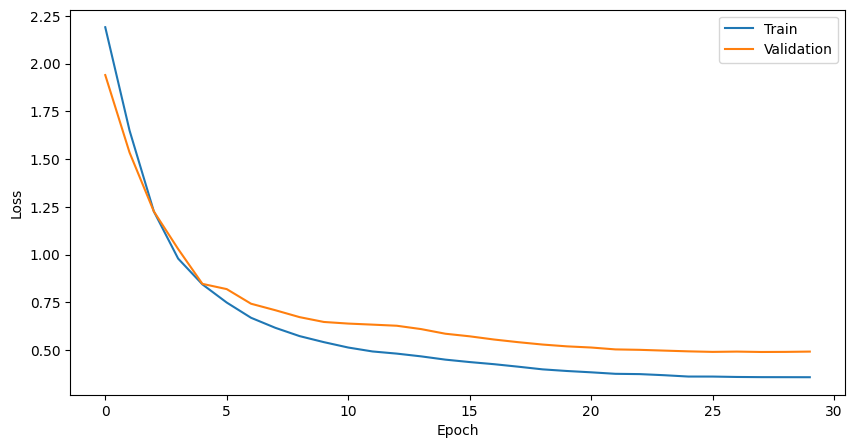

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train")

plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [31]:
from collections import Counter

counter = Counter()

for _, masks in train_loader:
    counter.update(masks.flatten().tolist())

print(counter)

Counter({3: 20076880, 1: 14750079, 0: 10682767, 5: 6166762, 8: 3719877, 4: 2845085, 11: 2503995, 6: 743859, 7: 714595, 2: 623349, 9: 405385, 10: 184967})


In [32]:
from collections import Counter

pred_counter = Counter()

model.eval()

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        pred_counter.update(preds.flatten().tolist())

print(pred_counter)

Counter({3: 6218222, 1: 5060724, 5: 3482102, 0: 1636986, 4: 550644, 8: 346852, 11: 157270})


In [36]:
@torch.no_grad()
def evaluate_test(model, loader, criterion, device, num_classes):

    model.eval()

    metric = IoUMetric(num_classes)

    running_loss = 0
    running_acc = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast():

            outputs = model(images)
            loss = criterion(outputs, masks)

        running_loss += loss.item()
        running_acc += pixel_accuracy(outputs, masks)

        metric.update(outputs, masks)

    miou, per_class_iou = metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        miou,
        per_class_iou
    )

In [37]:
test_loss, test_acc, test_iou, test_per_class_iou = evaluate_test(
    model,
    test_loader,
    criterion,
    device,
    NUM_CLASSES
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Pixel Accuracy : {test_acc:.4f}")
print(f"Test mIoU : {test_iou:.4f}")

/tmp/ipykernel_9969/1435277511.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Test Loss : 0.5865
Pixel Accuracy : 0.8050
Test mIoU : 0.3422


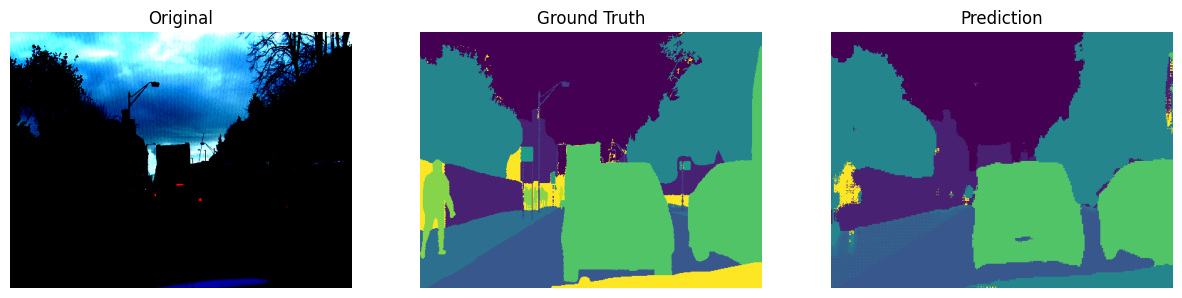

In [46]:
import matplotlib.pyplot as plt
import random

model.eval()

idx = random.randint(0, len(test_dataset)-1)

image, mask = test_dataset[idx]

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))
    pred = pred.argmax(1).squeeze().cpu()

image = image.permute(1,2,0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")
plt.axis("off")

plt.show()

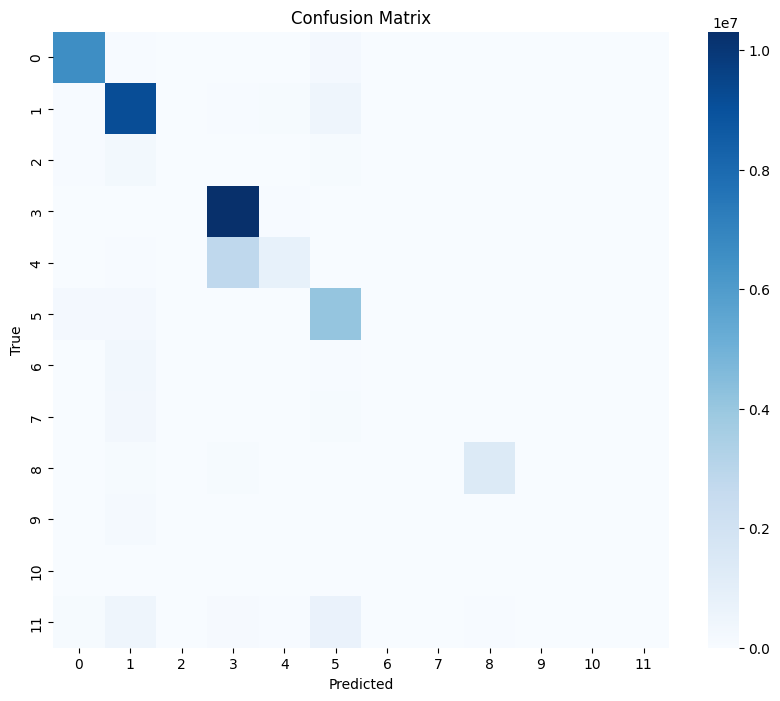

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        all_preds.extend(preds.view(-1).numpy())
        all_targets.extend(masks.view(-1).numpy())

cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [48]:
class_names = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Pavement",
    "Tree",
    "Sign",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist",
    "Unlabelled"
]

print("-"*35)

for i in range(NUM_CLASSES):

    print(f"{class_names[i]:12s}: {test_per_class_iou[i]:.4f}")

-----------------------------------
Sky         : 0.9062
Building    : 0.7623
Pole        : 0.0000
Road        : 0.7639
Pavement    : 0.2043
Tree        : 0.6550
Sign        : 0.0000
Fence       : 0.0000
Car         : 0.8050
Pedestrian  : 0.0000
Bicyclist   : 0.0000
Unlabelled  : 0.0099


In [49]:
import pandas as pd

iou_table = pd.DataFrame({

    "Class": class_names,
    "IoU": test_per_class_iou.numpy()

})

display(iou_table)

,Class,IoU
0,Sky,0.906155
1,Building,0.762330
2,Pole,0.000000
3,Road,0.763896
4,Pavement,0.204338
5,Tree,0.654971
6,Sign,0.000000
7,Fence,0.000000
8,Car,0.804964
9,Pedestrian,0.000000
